#########    All "our" in the following code refers to Joint Cabernet.

In [1]:
import pandas as pd
import numpy as np
from itertools import chain

# Hi-C utilities imports:
import cooler
import bioframe
import cooltools
from cooltools.lib.numutils import fill_diag
from packaging import version
if version.parse(cooltools.__version__) < version.parse('0.5.2'):
    raise AssertionError("tutorials rely on cooltools version 0.5.2 or higher,"+
                         "please check your cooltools version and update to the latest")

# Visualization imports:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib.patches as patches
from matplotlib.ticker import EngFormatter

# helper functions for plotting
bp_formatter = EngFormatter('b')
def format_ticks(ax, x=True, y=True, rotate=True):
    """format ticks with genomic coordinates as human readable"""
    if y:
        ax.yaxis.set_major_formatter(bp_formatter)
    if x:
        ax.xaxis.set_major_formatter(bp_formatter)
        ax.xaxis.tick_bottom()
    if rotate:
        ax.tick_params(axis='x',rotation=45)

import datetime
from tqdm.notebook import tqdm

from scipy.stats import pearsonr
from scipy.stats import gaussian_kde
from scipy.stats import binned_statistic

In [ ]:
# "indir" is a custom input path, and "outdir" is a custom output path.
# indir = ''
outdir = './'

In [ ]:
# get the RNA by sublass df
subclass_list = pd.read_csv('../../../03.data/04.config_files/subclass_order.csv', header=None)[0].to_list()
subclass_list=[i for i in subclass_list if "NN" not in i]

df_RNA=pd.read_csv('../../03.Joint-Cabernet.cellType_State/04-Correlation_calculation/all_cell_correlation/02-our_subclass_mean_dat_final.csv',index_col=0).T

max_threshold_=0.2
cv_threshold_=0.4
df_RNA_selected=df_RNA.loc[subclass_list,:]
df_RNA_selected=df_RNA_selected.loc[subclass_list,
    (df_RNA_selected.max(axis=0)>max_threshold_) &
    (df_RNA_selected.apply(lambda col: col.std() / col.mean(), axis=0)>cv_threshold_)
            ]

/tmp/ipykernel_10521/3666095234.py:12: RuntimeWarning: invalid value encountered in scalar divide
  (df_RNA_selected.apply(lambda col: col.std() / col.mean(), axis=0)>cv_threshold_)


In [4]:
df_RNA_selected

,ENSMUSG00000002459.17,ENSMUSG00000025905.13,ENSMUSG00000033740.17,ENSMUSG00000067879.3,ENSMUSG00000025915.14,ENSMUSG00000042501.12,ENSMUSG00000048960.13,ENSMUSG00000057715.13,ENSMUSG00000016918.15,ENSMUSG00000025938.16,...,ENSMUSG00000063434.5,ENSMUSG00000043531.16,ENSMUSG00000097636.7,ENSMUSG00000043639.14,ENSMUSG00000024981.6,ENSMUSG00000025085.16,ENSMUSG00000025089.15,ENSMUSG00000025092.6,ENSMUSG00000087095.2,ENSMUSG00000003228.8
L2/3 IT CTX Glut,0.514728,0.002892,0.044854,0.226865,0.401239,0.039873,0.077100,0.746375,0.093341,0.031954,...,1.731531,1.077693,0.006462,0.138960,0.139792,1.503690,0.040495,0.342812,0.077009,0.138162
L4/5 IT CTX Glut,0.234368,0.005700,0.045252,0.218639,0.231069,0.042969,0.067703,0.922805,0.028767,0.048081,...,0.819922,1.973580,0.003496,0.082188,0.196263,1.311148,0.058563,0.332559,0.023379,0.124285
L5 IT CTX Glut,0.301417,0.074027,0.050697,0.476340,0.240433,0.087553,0.086541,1.235155,0.215684,0.037116,...,1.953426,1.319674,0.003935,0.050022,0.157297,1.417625,0.066063,0.270491,0.011314,0.197072
L6 IT CTX Glut,0.250545,0.119963,0.036756,0.406675,0.276309,0.057813,0.131841,1.587347,0.747573,0.030990,...,1.860657,1.332079,0.011670,0.066528,0.147294,1.223675,0.040806,0.212130,0.004678,0.234160
IT AON-TT-DP Glut,0.324420,0.014120,0.034911,0.168316,0.298051,0.068886,0.192879,1.477304,0.240858,0.088805,...,1.065682,0.936945,0.007152,0.147187,0.126288,1.267522,0.053956,0.405244,0.072030,0.176216
LA-BLA-BMA-PA Glut,0.315862,0.002466,0.017635,0.000339,0.204269,0.156419,0.206263,1.475192,0.086062,0.057432,...,0.624720,1.433874,0.000000,0.015076,0.117470,1.282097,0.058372,0.229635,0.000287,0.298981
L2/3 IT RSP Glut,0.251099,0.007903,0.052549,0.194189,0.198190,0.119498,0.077849,0.711263,0.039551,0.040545,...,1.070824,1.447553,0.008792,0.098434,0.191200,1.118973,0.044370,0.313964,0.013851,0.105733
L4 RSP-ACA Glut,0.115259,0.002343,0.037028,0.169607,0.256681,0.722258,0.132767,1.085559,0.059817,0.072089,...,1.474571,0.592114,0.006005,0.086578,0.208496,0.988793,0.028799,0.407764,0.018907,0.116138
L5 ET CTX Glut,0.366215,0.006171,0.053892,0.378033,0.325558,0.069857,0.203598,1.582146,0.036809,0.056024,...,0.572815,2.305443,0.028576,0.082455,0.152500,0.847292,0.031017,0.456840,0.005023,0.140302
SUB-ProS Glut,0.307113,0.001455,0.129194,0.314935,0.222461,0.031959,0.232066,0.928539,0.022017,0.024764,...,0.500580,1.061090,0.242622,0.027029,0.111649,0.265203,0.885735,0.417370,0.072196,0.084257


In [ ]:
csv_path = "../../../03.data/02.metainfo/01.Young_Mouse/subclass_name.Joint_Cabernet_corresponding_to_3C.csv"
df = pd.read_csv(csv_path, sep=',')
df = df.iloc[:len(subclass_list),:]

In [6]:
# load the 3C data
print(f"initialization started  at {datetime.datetime.now()}")
resolution_=10_000

mcool_file={subclass_liu : f'{indir}/{subclass_liu}.Q.10K.mcool'
           for subclass_liu in df['subclass_liu']}
clr={subclass_liu : cooler.Cooler(f'{mcool_file[subclass_liu]}::resolutions/{resolution_}') for subclass_liu in df['subclass_liu']}
matrixes_={
    chrom_ : 
           [
               clr[subclass_liu].matrix(balance=True).fetch(chrom_)[:] 
                     for subclass_liu in df['subclass_liu']
           ] 
           for chrom_ in [f'chr{i}' for i in range(1,20,1)]
}
print(f"initialization finished at {datetime.datetime.now()}")

initialization started  at 2025-11-20 15:20:58.388957
initialization finished at 2025-11-20 15:38:27.358157


In [7]:
all_wanted_dots_df=pd.read_csv(f"{outdir}/intergenic_to_selectedGenes_dots.tsv", sep="\t", header=0,
                              dtype={"bin_status":str})

In [8]:
mm10_chromsizes = bioframe.fetch_chromsizes('mm10')
chrom_list=["chr"+str(i) for i in range(1,20)]
start_bin_index={"chr"+str(chrom_number) : int(np.sum([np.ceil(mm10_chromsizes["chr"+str(i)]/10_000) for i in range(1, chrom_number)])) for chrom_number in range(1,20)}
start_bin_index

{'chr1': 0,
 'chr2': 19548,
 'chr3': 37760,
 'chr4': 53764,
 'chr5': 69415,
 'chr6': 84599,
 'chr7': 99573,
 'chr8': 114118,
 'chr9': 127059,
 'chr10': 139519,
 'chr11': 152589,
 'chr12': 164798,
 'chr13': 176811,
 'chr14': 188854,
 'chr15': 201345,
 'chr16': 211750,
 'chr17': 221571,
 'chr18': 231070,
 'chr19': 240141}

In [ ]:
genes_df = pd.read_csv('../../../03.data/01.ref/mm10.genes.bed', sep='\t', header=None, names=['chromosome', 'start', 'end', 'gene_id', 'gene_name', 'gene_type', 'strand'])
genes_df=genes_df[genes_df["chromosome"].apply(lambda x: x in chrom_list)]
selected_genes_df=genes_df[genes_df["gene_id"].apply(lambda x : x in df_RNA_selected.columns)].copy()

In [10]:
selected_genes_df.loc[:,"start_bin"] = selected_genes_df["chromosome"].apply(lambda x : start_bin_index[x]) \
                                + (selected_genes_df["start"]/10_000).astype(int)
selected_genes_df.loc[:,"end_bin"] = selected_genes_df["chromosome"].apply(lambda x : start_bin_index[x]) \
                                + ((selected_genes_df["end"]-1)/10_000).astype(int)

In [11]:
selected_genes_df

,chromosome,start,end,gene_id,gene_name,strand,start_bin,end_bin
38,chr1,4909576,5070285,ENSMUSG00000002459.17,Rgs20,-,490,507
47,chr1,5588466,5606131,ENSMUSG00000025905.13,Oprk1,+,558,560
59,chr1,6487231,6860940,ENSMUSG00000033740.17,St18,+,648,686
105,chr1,9601199,9627143,ENSMUSG00000067879.3,AC103620.3,+,960,962
110,chr1,9798107,9900845,ENSMUSG00000025915.14,Sgk3,+,979,990
...,...,...,...,...,...,...,...,...
49865,chr19,57032733,57314919,ENSMUSG00000025085.16,Ablim1,-,245844,245872
49873,chr19,58235604,58455909,ENSMUSG00000025089.15,Gfra1,-,245964,245986
49883,chr19,58795751,58860984,ENSMUSG00000025092.6,Hspa12a,-,246020,246027
49894,chr19,59425104,59458635,ENSMUSG00000087095.2,Emx2os,-,246083,246086


In [12]:
selected_genes_df_by_chrom={chrom_ : selected_genes_df[selected_genes_df["chromosome"]==chrom_] for chrom_ in chrom_list}

In [13]:
all_wanted_dots_df

,chrom1,start1,end1,chrom2,start2,end2,bin1,bin2,kernel_id,iteration,score,pvalue,qvalue,subclass,bin1_intergenic,bin1_selected,bin2_intergenic,bin2_selected,bin_status
0,chr1,3050000,3060000,chr1,5040000,5050000,305,504,0,0,0.482867,1.000000e-10,1.000000e-10,L2/3 IT CTX Glut,True,False,False,True,1001
1,chr1,3110000,3120000,chr1,6740000,6750000,311,674,0,0,0.363741,6.510000e-08,6.850000e-08,L2/3 IT CTX Glut,True,False,False,True,1001
2,chr1,3110000,3120000,chr1,6790000,6800000,311,679,0,0,0.417278,3.000000e-10,4.000000e-10,L2/3 IT CTX Glut,True,False,False,True,1001
3,chr1,3690000,3700000,chr1,6520000,6530000,369,652,0,0,0.316687,2.920000e-08,3.150000e-08,L2/3 IT CTX Glut,True,False,False,True,1001
4,chr1,3730000,3740000,chr1,6680000,6690000,373,668,0,0,0.483908,0.000000e+00,0.000000e+00,L2/3 IT CTX Glut,True,False,False,True,1001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1143935,chr19,59760000,59770000,chr19,60950000,60960000,246117,246236,0,0,0.431532,8.000000e-10,9.000000e-10,ACB-BST-FS D1 Gaba,True,False,False,True,1001
1143936,chr19,59840000,59850000,chr19,60950000,60960000,246125,246236,0,0,0.534147,0.000000e+00,0.000000e+00,ACB-BST-FS D1 Gaba,True,False,False,True,1001
1143937,chr19,60090000,60100000,chr19,61010000,61020000,246150,246242,0,0,0.330801,4.860000e-08,5.060000e-08,ACB-BST-FS D1 Gaba,True,False,False,True,1001
1143938,chr19,60250000,60260000,chr19,60980000,60990000,246166,246239,0,0,0.483798,0.000000e+00,0.000000e+00,ACB-BST-FS D1 Gaba,True,False,False,True,1001


In [14]:
bbbb=0
for _, i in selected_genes_df.iterrows():
    chrom_, start_, end_ = i["chromosome"], int(i["start"]), int(i["end"])
    if sum((selected_genes_df["chromosome"] == chrom_) & \
    (
        (
        (start_>=selected_genes_df["start"]) & (start_<selected_genes_df["end"])
    ) | (
        (end_>selected_genes_df["start"]) & (end_<=selected_genes_df["end"])
    )
    )) !=1:
        bbbb+=1
bbbb

84

In [15]:
# selected_genes_df also contains overlapping genes

In [16]:
def calculate_PCC_3C_RNA(dot_):
    # dot_ is a row from all_wanted_dots_df
    chrom_=dot_["chrom1"]
    bin_status_=dot_["bin_status"]
    if bin_status_=="1001":
        bin_intergenic=dot_["bin1"]
        bin_gene=dot_["bin2"]
    elif bin_status_=="0110":
        bin_intergenic=dot_["bin2"]
        bin_gene=dot_["bin1"]
    else:
        raise("wrong bin_status!")

    genes_df_1 = selected_genes_df_by_chrom[chrom_]
    genes_df_2 = genes_df_1[(genes_df_1["start_bin"]<=bin_gene) & (genes_df_1["end_bin"]>=bin_gene)]
    
    matrix_=matrixes_[chrom_]
    
    bin_intergenic_chrom_ = bin_intergenic - start_bin_index[chrom_]

    output_list=[]

    for _, i in genes_df_2.iterrows():
        start_bin, end_bin = i[["start_bin", "end_bin"]]
        start_bin_chrom_ = start_bin - start_bin_index[chrom_]
        end_bin_chrom_ = end_bin - start_bin_index[chrom_]
        list_for_3C=[
            np.nansum(
                matrix_i[bin_intergenic_chrom_:(bin_intergenic_chrom_+1),
            start_bin_chrom_:(end_bin_chrom_+1)]
            ) 
            for matrix_i in matrix_
        ]
        if max(list_for_3C) == min(list_for_3C):
            continue

        gene_id_=i["gene_id"]
        RNA_=df_RNA_selected.loc[:, gene_id_]

        coef, p_value = pearsonr(RNA_, list_for_3C)
        if ~np.isnan(coef):
            output_list.append((bin_intergenic, bin_gene,
                                 chrom_, bin_intergenic_chrom_,
                                 gene_id_, coef))
    return output_list      

In [31]:
temp_df=all_wanted_dots_df.iloc[0:10000].copy()

In [32]:
temp_df["PCC_3C_RNA"]=temp_df.apply(calculate_PCC_3C_RNA, axis=1)

<Axes: >

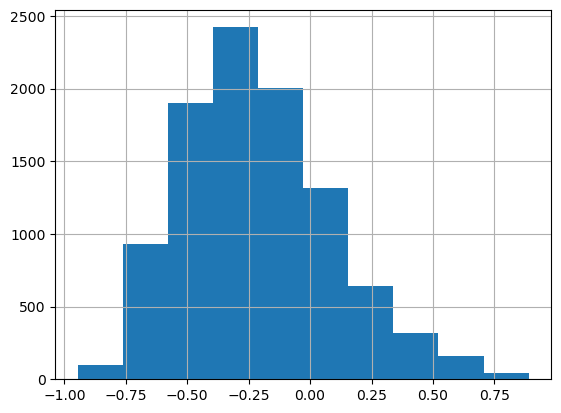

In [33]:
temp_df["PCC_3C_RNA"].apply(lambda x : x[0][5] if len(x)>0 else None).hist()

In [35]:
print(f'{datetime.datetime.now()} starting..')
all_wanted_dots_df["PCC_3C_RNA"]=all_wanted_dots_df.apply(calculate_PCC_3C_RNA, axis=1)
print(f'{datetime.datetime.now()} finished.')

2025-11-20 15:55:37.664917 starting..
2025-11-20 16:30:57.699482 finished.


In [36]:
all_wanted_dots_df

,chrom1,start1,end1,chrom2,start2,end2,bin1,bin2,kernel_id,iteration,score,pvalue,qvalue,subclass,bin1_intergenic,bin1_selected,bin2_intergenic,bin2_selected,bin_status,PCC_3C_RNA
0,chr1,3050000,3060000,chr1,5040000,5050000,305,504,0,0,0.482867,1.000000e-10,1.000000e-10,L2/3 IT CTX Glut,True,False,False,True,1001,"[(305, 504, chr1, 305, ENSMUSG00000002459.17, ..."
1,chr1,3110000,3120000,chr1,6740000,6750000,311,674,0,0,0.363741,6.510000e-08,6.850000e-08,L2/3 IT CTX Glut,True,False,False,True,1001,"[(311, 674, chr1, 311, ENSMUSG00000033740.17, ..."
2,chr1,3110000,3120000,chr1,6790000,6800000,311,679,0,0,0.417278,3.000000e-10,4.000000e-10,L2/3 IT CTX Glut,True,False,False,True,1001,"[(311, 679, chr1, 311, ENSMUSG00000033740.17, ..."
3,chr1,3690000,3700000,chr1,6520000,6530000,369,652,0,0,0.316687,2.920000e-08,3.150000e-08,L2/3 IT CTX Glut,True,False,False,True,1001,"[(369, 652, chr1, 369, ENSMUSG00000033740.17, ..."
4,chr1,3730000,3740000,chr1,6680000,6690000,373,668,0,0,0.483908,0.000000e+00,0.000000e+00,L2/3 IT CTX Glut,True,False,False,True,1001,"[(373, 668, chr1, 373, ENSMUSG00000033740.17, ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1143935,chr19,59760000,59770000,chr19,60950000,60960000,246117,246236,0,0,0.431532,8.000000e-10,9.000000e-10,ACB-BST-FS D1 Gaba,True,False,False,True,1001,"[(246117, 246236, chr19, 5976, ENSMUSG00000003..."
1143936,chr19,59840000,59850000,chr19,60950000,60960000,246125,246236,0,0,0.534147,0.000000e+00,0.000000e+00,ACB-BST-FS D1 Gaba,True,False,False,True,1001,"[(246125, 246236, chr19, 5984, ENSMUSG00000003..."
1143937,chr19,60090000,60100000,chr19,61010000,61020000,246150,246242,0,0,0.330801,4.860000e-08,5.060000e-08,ACB-BST-FS D1 Gaba,True,False,False,True,1001,"[(246150, 246242, chr19, 6009, ENSMUSG00000003..."
1143938,chr19,60250000,60260000,chr19,60980000,60990000,246166,246239,0,0,0.483798,0.000000e+00,0.000000e+00,ACB-BST-FS D1 Gaba,True,False,False,True,1001,"[(246166, 246239, chr19, 6025, ENSMUSG00000003..."


In [38]:
all_wanted_dots_df.to_csv(f"{outdir}/intergenic_to_selectedGenes_dots_withPCC_3C_RNA.tsv", sep="\t", index=False)

<Axes: >

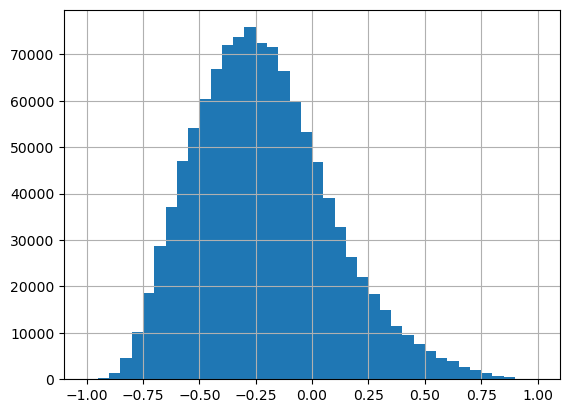

In [39]:
all_wanted_dots_df["PCC_3C_RNA"].apply(lambda x : x[0][5] if x else np.nan).hist(range=(-1,1), bins=40)

(159, 20)


<Axes: >

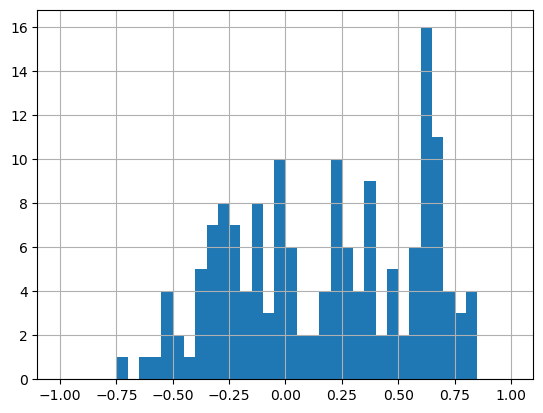

In [40]:
dots_within500kb = all_wanted_dots_df[((all_wanted_dots_df["bin2"]-all_wanted_dots_df["bin1"]) >= 2) & ((all_wanted_dots_df["bin2"]-all_wanted_dots_df["bin1"]) <= 3)]
print(dots_within500kb.shape)
dots_within500kb["PCC_3C_RNA"].apply(lambda x : x[0][5] if x else np.nan).hist(range=(-1,1), bins=40)

In [41]:
distance_list=[2,3,4,5,6,7,8,9,10,15,20,25,30,40,50,75,100,150,200,250,300,350,400,450,500]

for q1, q2 in zip(distance_list, distance_list[1:]):
    dots_within500kb = all_wanted_dots_df[((all_wanted_dots_df["bin2"]-all_wanted_dots_df["bin1"]) >= q1) & ((all_wanted_dots_df["bin2"]-all_wanted_dots_df["bin1"]) <= q2)]
    print(dots_within500kb.shape, f'{q1}<=distance/10kb<{q2}', np.nanmean(dots_within500kb["PCC_3C_RNA"].apply(lambda x : x[0][5] if x else np.nan)))

(159, 20) 2<=distance/10kb<3 0.17516067263689813
(381, 20) 3<=distance/10kb<4 0.1801340746834191
(689, 20) 4<=distance/10kb<5 0.18807282434564151
(1042, 20) 5<=distance/10kb<6 0.16716847511889135
(1366, 20) 6<=distance/10kb<7 0.20985250546943607
(1578, 20) 7<=distance/10kb<8 0.2517788028210596
(1654, 20) 8<=distance/10kb<9 0.26225067733550395
(1625, 20) 9<=distance/10kb<10 0.28176557300560723
(4730, 20) 10<=distance/10kb<15 0.25333285975088093
(5321, 20) 15<=distance/10kb<20 0.17926507873584158
(6155, 20) 20<=distance/10kb<25 0.08001048060569528
(7121, 20) 25<=distance/10kb<30 0.027249225520120872
(14886, 20) 30<=distance/10kb<40 -0.05157648748195698
(17028, 20) 40<=distance/10kb<50 -0.1319562279264913
(46625, 20) 50<=distance/10kb<75 -0.1967488392741888
(52871, 20) 75<=distance/10kb<100 -0.23758711762832582
(114346, 20) 100<=distance/10kb<150 -0.25397194140179846
(120044, 20) 150<=distance/10kb<200 -0.2538446716674343
(123263, 20) 200<=distance/10kb<250 -0.24909256839820892
(128692, 2

In [42]:
import seaborn as sns

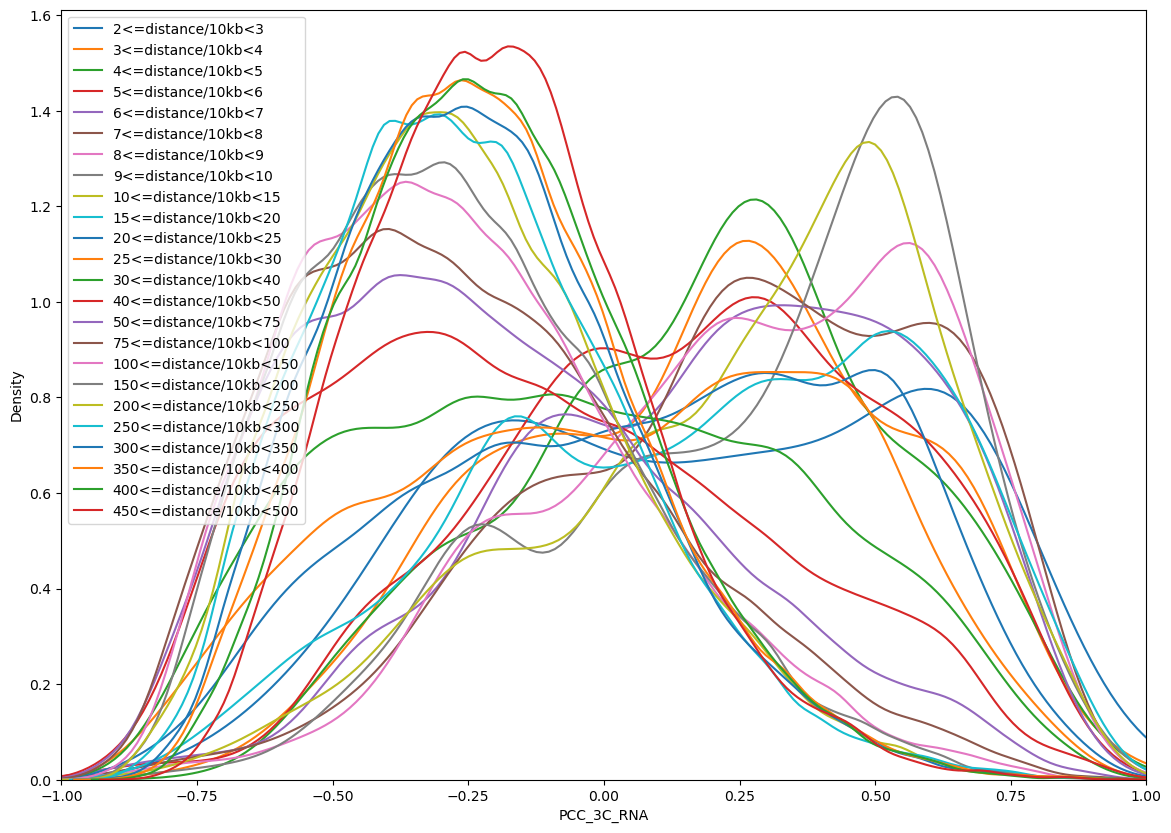

In [43]:
distance_list=[2,3,4,5,6,7,8,9,10,15,20,25,30,40,50,75,100,150,200,250,300,350,400,450,500]
plt.figure(figsize=(14,10))
for q1, q2 in zip(distance_list, distance_list[1:]):
    dots_within500kb = all_wanted_dots_df[((all_wanted_dots_df["bin2"]-all_wanted_dots_df["bin1"]) >= q1) & ((all_wanted_dots_df["bin2"]-all_wanted_dots_df["bin1"]) <= q2)]
    sns.kdeplot(dots_within500kb["PCC_3C_RNA"].apply(lambda x : x[0][5] if x else np.nan), label=f'{q1}<=distance/10kb<{q2}', bw_adjust=1)
plt.xlim(-1,1)
plt.legend()

/share/home/renlh/miniconda3/envs/default/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/share/home/renlh/miniconda3/envs/default/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/share/home/renlh/miniconda3/envs/default/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/share/home/renlh/miniconda3/envs/default/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate

<Figure size 1400x1000 with 0 Axes>

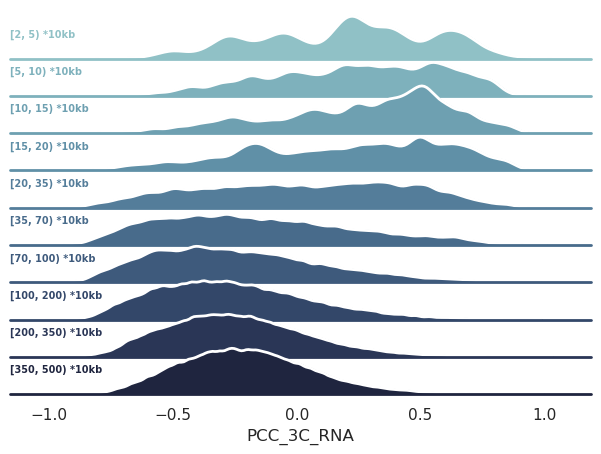

In [44]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Set theme for the plot
sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

plt.figure(figsize=(14,10))
distance_list = [2, 5, 10, 15, 20, 35, 70, 100, 200, 350, 500]

# Prepare data
# Create a DataFrame for the distance range and corresponding "PCC_3C_RNA" values
data_list = []

for q1, q2 in zip(distance_list, distance_list[1:]):
    dots_within500kb = all_wanted_dots_df[((all_wanted_dots_df["bin2"] - all_wanted_dots_df["bin1"]) >= q1) & 
                                          ((all_wanted_dots_df["bin2"] - all_wanted_dots_df["bin1"]) < q2)]
    data = dots_within500kb["PCC_3C_RNA"].apply(lambda x: x[0][5] if x else np.nan)
    for value in data:
        data_list.append({"PCC_3C_RNA": value, "distance_range": f'[{q1}, {q2}) *10kb'})

# Create a DataFrame from the list
df = pd.DataFrame(data_list)

# Initialize the FacetGrid object
pal = sns.cubehelix_palette(10, rot=-.25, light=.7)
g = sns.FacetGrid(df, row="distance_range", hue="distance_range", aspect=15, height=.5, palette=pal)

# Draw the densities in a few steps
g.map(sns.kdeplot, "PCC_3C_RNA",
      bw_adjust=.5, clip_on=(-1,1),
      fill=True, alpha=1, linewidth=1.5)
g.map(sns.kdeplot, "PCC_3C_RNA", clip_on=(-1,1), color="w", lw=2, bw_adjust=.5)

# Add a reference line at y=0
g.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=False)

# Define and use a simple function to label the plot in axes coordinates
def label(x, color, label):
    ax = plt.gca()
    ax.text(0, .5, label, fontweight="bold", color=color,
            ha="left", va="center", transform=ax.transAxes, size=7)

g.map(label, "PCC_3C_RNA")

# Set the subplots to overlap
g.figure.subplots_adjust(hspace=-.25)

# Remove axes details that don't play well with overlap
g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)

# Show the plot
plt.show()
